In [5]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier

# Imbalance handling
from imblearn.over_sampling import RandomOverSampler

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# XGBoost
import xgboost as xgb

In [6]:
df = pd.read_csv("PCOS_data.csv")
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [7]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,271.000000,0.327172,31.430684,59.637153,156.484835,24.307579,13.802218,73.247689,19.243993,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,4.055129,1.840812,4.430285,1.688629,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,1.000000,0.000000,20.000000,31.000000,137.000000,12.400000,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,136.000000,0.000000,28.000000,52.000000,152.000000,21.600000,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,271.000000,0.000000,31.000000,59.000000,156.000000,24.200000,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,406.000000,1.000000,35.000000,65.000000,160.000000,26.600000,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


In [8]:
drop_cols = ["Sl. No", "Patient File No.", "Unnamed: 44"]
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [9]:
for col in df.columns:
    if df[col].dtype != 'object':
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_712/2695058295.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_712/2695058295.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [10]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [11]:
X = df.drop("PCOS (Y/N)", axis=1)
y = df["PCOS (Y/N)"]

In [12]:
X

,Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,28,44.6,152.000,19.3,15,78,22,10.48,2,5,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,36,65.0,161.500,24.9,15,74,20,11.70,2,5,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,33,68.8,165.000,25.3,11,72,18,11.80,2,5,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,37,65.0,148.000,29.7,13,72,20,12.00,2,5,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,25,52.0,161.000,20.1,11,72,18,10.00,2,5,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,35,50.0,164.592,18.5,17,72,16,11.00,2,5,...,0,0.0,0,110,70,1,0,17.5,10.0,6.7
537,30,63.2,158.000,25.3,15,72,18,10.80,2,5,...,0,0.0,0,110,70,9,7,19.0,18.0,8.2
538,36,54.0,152.000,23.4,13,74,20,10.80,2,6,...,0,0.0,0,110,80,1,0,18.0,9.0,7.3
539,27,50.0,150.000,22.2,15,74,20,12.00,4,2,...,1,0.0,0,110,70,7,6,18.0,16.0,11.5


In [14]:
y

,PCOS (Y/N)
0,0
1,0
2,1
3,0
4,0
...,...
536,0
537,0
538,0
539,0


In [15]:
skb = SelectKBest(score_func=chi2, k=20)
X_skb = skb.fit_transform(X, y)

selected_features_skb = X.columns[skb.get_support()]
print("SelectKBest Features:\n", selected_features_skb)

SelectKBest Features:
 Index([' Age (yrs)', 'Weight (Kg)', 'BMI', 'Cycle(R/I)',
       'Marraige Status (Yrs)', '  I   beta-HCG(mIU/mL)',
       'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
       'AMH(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'Weight gain(Y/N)',
       'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Follicle No. (L)', 'Follicle No. (R)'],
      dtype='object')


In [16]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X, y)

importances = xgb_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

selected_features_xgb = feat_imp.sort_values(ascending=False).head(20).index
print("XGBoost Features:\n", selected_features_xgb)

XGBoost Features:
 Index(['Follicle No. (R)', 'hair growth(Y/N)', 'Weight gain(Y/N)',
       'Follicle No. (L)', 'Skin darkening (Y/N)', 'Cycle length(days)',
       'Fast food (Y/N)', 'II    beta-HCG(mIU/mL)', 'Cycle(R/I)',
       'BP _Diastolic (mmHg)', 'Avg. F size (L) (mm)', 'PRG(ng/mL)', 'FSH/LH',
       'BMI', 'Weight (Kg)', 'Avg. F size (R) (mm)', 'Pimples(Y/N)',
       'Vit D3 (ng/mL)', 'Hip(inch)', 'Reg.Exercise(Y/N)'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:48:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [17]:
final_features = list(set(selected_features_skb).intersection(set(selected_features_xgb)))
print("Final Selected Features:", final_features)

X = X[final_features]

Final Selected Features: ['II    beta-HCG(mIU/mL)', 'Follicle No. (L)', 'Vit D3 (ng/mL)', 'Skin darkening (Y/N)', 'BMI', 'Weight (Kg)', 'Weight gain(Y/N)', 'Cycle(R/I)', 'Follicle No. (R)', 'Fast food (Y/N)', 'hair growth(Y/N)', 'PRG(ng/mL)', 'Pimples(Y/N)', 'FSH/LH']


In [19]:
len(final_features)

14

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_scaled, y)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    stratify=y_resampled,
    random_state=42
)

In [23]:
lr = LogisticRegression()
svm = SVC(probability=True)
rf = RandomForestClassifier()
knn = KNeighborsClassifier()
lgbm = LGBMClassifier()

In [24]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(svm, param_grid, cv=5)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

In [25]:
models = {
    "Logistic Regression": lr,
    "SVM": best_svm,
    "Random Forest": rf,
    "KNN": knn,
    "LGBM": lgbm
}

for name, model in models.items():
    model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 730
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [26]:
def evaluate(model, name):
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [27]:
for name, model in models.items():
    evaluate(model, name)


Logistic Regression
Accuracy: 0.9315068493150684
Precision: 0.9315068493150684
Recall: 0.9315068493150684
F1 Score: 0.9315068493150684

SVM
Accuracy: 0.9383561643835616
Precision: 0.9444444444444444
Recall: 0.9315068493150684
F1 Score: 0.9379310344827586

Random Forest
Accuracy: 0.952054794520548
Precision: 0.9583333333333334
Recall: 0.9452054794520548
F1 Score: 0.9517241379310345

KNN
Accuracy: 0.8835616438356164
Precision: 0.8783783783783784
Recall: 0.8904109589041096
F1 Score: 0.8843537414965986

LGBM
Accuracy: 0.958904109589041
Precision: 0.958904109589041
Recall: 0.958904109589041
F1 Score: 0.958904109589041


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [28]:
voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', best_svm),
        ('rf', rf),
        ('knn', knn)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)
evaluate(voting, "Voting Classifier")


Voting Classifier
Accuracy: 0.952054794520548
Precision: 0.9583333333333334
Recall: 0.9452054794520548
F1 Score: 0.9517241379310345


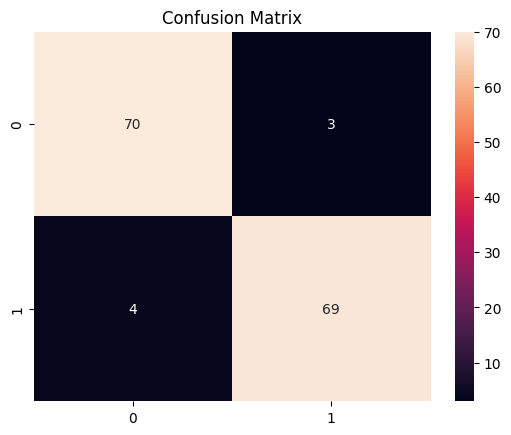

In [29]:
y_pred = voting.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()